# Sistemas Lineares

**Módulo:** 03 – Progressões, Matrizes e Sistemas Lineares

**Pré-requisitos:** [`0304a_matrizes.ipynb`](0304a_matrizes.ipynb) (operações elementares sobre linhas, matriz inversível) e [`0305a_determinantes.ipynb`](0305a_determinantes.ipynb) (cálculo de determinante, matriz inversa via adjunta).

**Objetivos de aprendizagem:**
- Representar um sistema linear na forma matricial Ax = b e classificá-lo quanto ao número de soluções (SPD, SPI, SI).
- Resolver sistemas lineares pelo Teorema de Cramer e por escalonamento (eliminação de Gauss).
- Reconhecer sistemas homogêneos e calcular a característica (posto) de uma matriz.
- Aplicar o Teorema de Rouché-Capelli e resolver sistemas via matriz inversa.

**Tempo estimado:** 90 a 105 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/03_progressoes_matrizes_e_sistemas_lineares/0306a_sistemas_lineares.ipynb)

📖 **Leitura complementar:** [Sistema de equações lineares](https://pt.wikipedia.org/wiki/Sistema_de_equa%C3%A7%C3%B5es_lineares)

## Quanto custa cada item?

Na fila do caixa de uma papelaria, você repara em dois tíquetes colados no balcão, de dois clientes anteriores:

- 3 cadernos e 2 canetas: R$ 22
- 1 caderno e 3 canetas: R$ 19

Nenhum dos dois tíquetes diz o preço individual de caderno ou caneta — só o total pago. Mesmo assim, será que dá pra descobrir quanto custa cada item, só com essas duas informações?

Com duas incógnitas, ainda dá pra resolver na base da tentativa — testando alguns valores até um par bater com os dois tíquetes. Mas e se, no dia seguinte, a papelaria também vender borrachas, e um terceiro tíquete misturar os três itens? Ou se fossem dez itens diferentes, com dez tíquetes? Tentativa e erro vira inviável rapidinho.

Esse notebook mostra como resolver esse tipo de problema — de duas ou de cem incógnitas — de forma sistemática, usando tudo que você já viu sobre matrizes e determinantes.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def desenhar_aumentada(ax, aumentada: np.ndarray, titulo: str = "", linha_destaque: int | None = None) -> None:
    '''Desenha uma matriz aumentada [A|b] como grade de células, com uma linha vertical separando A de b.'''
    linhas, colunas_totais = aumentada.shape
    colunas_a = colunas_totais - 1
    for i in range(linhas):
        for j in range(colunas_totais):
            cor_celula = COR_DESTAQUE if i == linha_destaque else NORD_PAINEL
            ax.add_patch(
                plt.Rectangle(
                    (j, linhas - 1 - i), 1, 1,
                    facecolor=cor_celula, edgecolor=NORD_LINHA, linewidth=1.2,
                )
            )
            ax.text(
                j + 0.5, linhas - 1 - i + 0.5, f"{aumentada[i, j]:g}",
                ha="center", va="center", color=NORD_TEXTO, fontsize=12,
            )
    ax.plot([colunas_a, colunas_a], [0, linhas], color=NORD_TEXTO, linewidth=2)
    ax.set_xlim(0, colunas_totais)
    ax.set_ylim(0, linhas)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    ax.set_title(titulo, color=NORD_TEXTO, fontsize=11)
    for spine in ax.spines.values():
        spine.set_visible(False)

## 1. O sistema linear: forma Ax = b

Um **sistema linear** é um conjunto de equações lineares que devem ser satisfeitas **ao mesmo tempo** pelas mesmas incógnitas. O problema da papelaria é exatamente isso: chamando de `c` o preço do caderno e `p` o preço da caneta,

- 3c + 2p = 22
- c + 3p = 19

são duas equações lineares nas incógnitas c e p, e queremos os valores que resolvem as duas ao mesmo tempo.

📌 **Forma matricial de um sistema linear:** todo sistema linear pode ser escrito como

**A x = b**

onde **A** é a matriz dos coeficientes, **x** é o vetor das incógnitas e **b** é o vetor dos termos independentes. Para o sistema da papelaria:

A = [[3, 2], [1, 3]] · x = [c, p] · b = [22, 19]

In [2]:
A_papelaria_2x2 = np.array([[3, 2], [1, 3]])
b_papelaria_2x2 = np.array([22, 19])

print("Sistema de equações:")
print("  3c + 2p = 22")
print("   c + 3p = 19")
print(f"\nForma matricial Ax = b:\nA =\n{A_papelaria_2x2}\nb = {b_papelaria_2x2}")

Sistema de equações:
  3c + 2p = 22
   c + 3p = 19

Forma matricial Ax = b:
A =
[[3 2]
 [1 3]]
b = [22 19]


**Representação numérica — tentativa e erro:** antes de aprender um método sistemático, vale ver por que "chutar" fica ruim rápido. A tabela abaixo testa alguns palpites para (c, p):

In [3]:
tentativas = pd.DataFrame({
    "caderno (c)": [3, 4, 5, 6],
    "caneta (p)": [5, 5, 5, 4],
})
tentativas["3c + 2p"] = 3 * tentativas["caderno (c)"] + 2 * tentativas["caneta (p)"]
tentativas["c + 3p"] = tentativas["caderno (c)"] + 3 * tentativas["caneta (p)"]
tentativas["bate com os dois tiquetes?"] = (
    (tentativas["3c + 2p"] == 22) & (tentativas["c + 3p"] == 19)
)
tentativas

,caderno (c),caneta (p),3c + 2p,c + 3p,bate com os dois tiquetes?
0,3,5,19,18,False
1,4,5,22,19,True
2,5,5,25,20,False
3,6,4,26,18,False


**Representação gráfica:** cada equação é uma reta no plano (c, p). O ponto onde as duas retas se cruzam é a solução do sistema — o único par (c, p) que satisfaz as duas equações ao mesmo tempo.

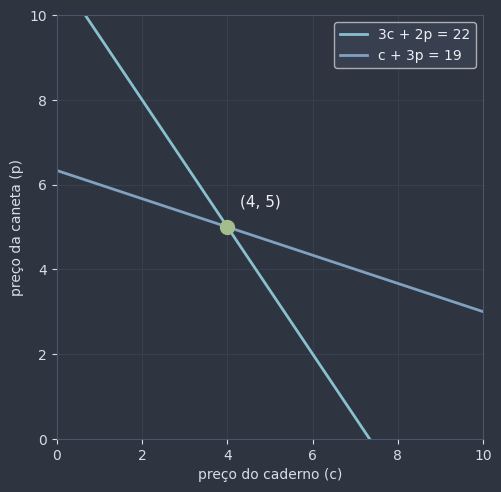

Solução: caderno = R$ 4, caneta = R$ 5


In [4]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

cs = np.linspace(0, 10, 200)
ax.plot(cs, (22 - 3 * cs) / 2, color=COR_PONTO, linewidth=2, label="3c + 2p = 22")
ax.plot(cs, (19 - cs) / 3, color=COR_SECUNDARIA, linewidth=2, label="c + 3p = 19")

solucao_papelaria = np.linalg.solve(A_papelaria_2x2, b_papelaria_2x2)
ax.plot(*solucao_papelaria, "o", color=COR_DESTAQUE, markersize=10, zorder=5)
ax.annotate(
    f"({solucao_papelaria[0]:.0f}, {solucao_papelaria[1]:.0f})",
    xy=solucao_papelaria, xytext=(solucao_papelaria[0] + 0.3, solucao_papelaria[1] + 0.5),
    color=NORD_TEXTO, fontsize=11,
)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xlabel("preço do caderno (c)", color=NORD_TEXTO_SEC)
ax.set_ylabel("preço da caneta (p)", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, loc="upper right")
plt.show()

print(f"Solução: caderno = R$ {solucao_papelaria[0]:.0f}, caneta = R$ {solucao_papelaria[1]:.0f}")

**Pergunta de checagem:** se você soubesse apenas o primeiro tíquete (3c + 2p = 22), conseguiria determinar c e p de forma única? Olhando pro gráfico, o que representaria essa única equação sozinha?

## 2. Classificando um sistema: SPD, SPI e SI

Nem todo sistema linear tem uma solução única. Um sistema com duas equações e duas incógnitas pode ter:

📌 **Classificação de um sistema linear:**
- **SPD** (sistema possível e determinado): existe **exatamente uma** solução.
- **SPI** (sistema possível e indeterminado): existem **infinitas** soluções.
- **SI** (sistema impossível): **não existe** nenhuma solução.

No caso 2×2, cada equação é uma reta no plano, e resolver o sistema é achar os pontos que pertencem às duas retas ao mesmo tempo:

- Retas **concorrentes** (se cruzam em um único ponto) → SPD
- Retas **coincidentes** (são a mesma reta) → SPI
- Retas **paralelas distintas** (nunca se cruzam) → SI

🕹️ **Widget interativo:** mexa nos sliders dos coeficientes das duas retas e observe a classificação mudar em tempo real.

In [5]:
def classificar_sistema_2x2(a1: float, b1: float, c1: float, a2: float, b2: float, c2: float) -> str:
    '''Classifica um sistema 2x2 (a1 x + b1 y = c1; a2 x + b2 y = c2) em SPD, SPI ou SI.'''
    det = a1 * b2 - a2 * b1
    if not np.isclose(det, 0):
        return "SPD"
    det_x = c1 * b2 - c2 * b1
    det_y = a1 * c2 - a2 * c1
    if np.isclose(det_x, 0) and np.isclose(det_y, 0):
        return "SPI"
    return "SI"


def mostrar_classificacao_2x2(a1: float, b1: float, c1: float, a2: float, b2: float, c2: float) -> None:
    classificacao = classificar_sistema_2x2(a1, b1, c1, a2, b2, c2)
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    xs = np.linspace(-10, 10, 200)
    if abs(b1) > 1e-9:
        ax.plot(xs, (c1 - a1 * xs) / b1, color=COR_PONTO, linewidth=2, label="reta 1")
    elif abs(a1) > 1e-9:
        ax.axvline(c1 / a1, color=COR_PONTO, linewidth=2, label="reta 1")
    if abs(b2) > 1e-9:
        ax.plot(xs, (c2 - a2 * xs) / b2, color=COR_SECUNDARIA, linewidth=2, label="reta 2")
    elif abs(a2) > 1e-9:
        ax.axvline(c2 / a2, color=COR_SECUNDARIA, linewidth=2, label="reta 2")

    if classificacao == "SPD":
        ponto = np.linalg.solve([[a1, b1], [a2, b2]], [c1, c2])
        ax.plot(*ponto, "o", color=COR_DESTAQUE, markersize=10, zorder=5)

    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, loc="upper right")
    cor_titulo = {"SPD": COR_DESTAQUE, "SPI": COR_AVISO, "SI": COR_ALERTA}[classificacao]
    ax.set_title(f"Classificação: {classificacao}", color=cor_titulo, fontsize=13)
    plt.show()


widgets.interact(
    mostrar_classificacao_2x2,
    a1=widgets.FloatSlider(value=1, min=-5, max=5, step=0.5, description="a1:"),
    b1=widgets.FloatSlider(value=1, min=-5, max=5, step=0.5, description="b1:"),
    c1=widgets.FloatSlider(value=3, min=-10, max=10, step=0.5, description="c1:"),
    a2=widgets.FloatSlider(value=1, min=-5, max=5, step=0.5, description="a2:"),
    b2=widgets.FloatSlider(value=-1, min=-5, max=5, step=0.5, description="b2:"),
    c2=widgets.FloatSlider(value=1, min=-10, max=10, step=0.5, description="c2:"),
)

interactive(children=(FloatSlider(value=1.0, description='a1:', max=5.0, min=-5.0, step=0.5), FloatSlider(valu…

<function __main__.mostrar_classificacao_2x2(a1: float, b1: float, c1: float, a2: float, b2: float, c2: float) -> None>

**Pergunta de checagem:** ajuste os sliders até deixar as duas retas com o mesmo coeficiente angular (mesma "inclinação"). É possível o sistema continuar sendo SPD nessa situação? Por quê?

## 3. Teorema de Cramer

Voltando ao sistema da papelaria, dá pra resolver Ax = b usando os determinantes vistos no notebook anterior:

📌 **Teorema de Cramer:** se det(A) ≠ 0, cada incógnita xᵢ de um sistema Ax = b é dada por

xᵢ = Dᵢ / D

onde D = det(A) e Dᵢ é o determinante da matriz A com a i-ésima coluna substituída pelo vetor b.

In [6]:
D = np.linalg.det(A_papelaria_2x2)

A_c = A_papelaria_2x2.copy()
A_c[:, 0] = b_papelaria_2x2  # substitui a coluna de c pelo vetor b
D_c = np.linalg.det(A_c)

A_p = A_papelaria_2x2.copy()
A_p[:, 1] = b_papelaria_2x2  # substitui a coluna de p pelo vetor b
D_p = np.linalg.det(A_p)

c_cramer = D_c / D
p_cramer = D_p / D

print(f"D  = det(A)                    = {D:.0f}")
print(f"D_c = det(A com coluna c -> b) = {D_c:.0f}  ->  c = D_c / D = {c_cramer:.0f}")
print(f"D_p = det(A com coluna p -> b) = {D_p:.0f}  ->  p = D_p / D = {p_cramer:.0f}")

D  = det(A)                    = 7
D_c = det(A com coluna c -> b) = 28  ->  c = D_c / D = 4
D_p = det(A com coluna p -> b) = 35  ->  p = D_p / D = 5


⚠️ **Erro comum:** o Teorema de Cramer só resolve sistemas com det(A) ≠ 0 (SPD) — se det(A) = 0, as divisões acima nem fazem sentido. Além disso, calcular determinantes de matrizes grandes é caro computacionalmente (o custo cresce muito rápido com a ordem). Para sistemas com muitas incógnitas, Cramer é mais didático do que prático — bom motivo pra conhecer o próximo método.

🔗 [Regra de Cramer](https://pt.wikipedia.org/wiki/Regra_de_Cramer)

**Pergunta de checagem:** se D = det(A) fosse igual a zero, o que isso diria sobre a existência de uma solução única para o sistema?

## 4. Sistemas escalonados

📌 **Sistema escalonado:** um sistema está na forma escalonada (ou "em escada") quando cada equação, de cima para baixo, tem uma incógnita a menos que a anterior. Por exemplo:

- x − y + 2z = 9
- ..... y + z = 4
- .......... z = 2

Um sistema escalonado é fácil de resolver por **substituição de trás pra frente**: a última equação já dá o valor de uma incógnita diretamente; substituindo esse valor na equação de cima, sobra só mais uma incógnita; e assim por diante.

In [8]:
# Sistema já escalonado: resolvendo de baixo para cima
z_esc = 2
y_esc = 4 - z_esc
x_esc = 9 + y_esc - 2 * z_esc

print(f"Da 3a equação:  z = {z_esc}")
print(f"Da 2a equação:  y = 4 - z = {y_esc}")
print(f"Da 1a equação:  x = 9 + y - 2z = {x_esc}")
print(f"\nSolução: (x, y, z) = ({x_esc}, {y_esc}, {z_esc})")

Da 3a equação:  z = 2
Da 2a equação:  y = 4 - z = 2
Da 1a equação:  x = 9 + y - 2z = 7

Solução: (x, y, z) = (7, 2, 2)


💡 **Dica:** a forma escalonada é o "alvo" do próximo bloco — todo sistema pode ser transformado numa forma escalonada equivalente, mesmo que não comece assim.

**Pergunta de checagem:** por que a *ordem* das equações importa tanto aqui — resolver de cima para baixo funcionaria tão facilmente quanto resolver de baixo para cima?

## 5. Escalonamento: eliminação de Gauss

Dois sistemas são **equivalentes** quando têm exatamente a mesma solução, mesmo escritos de formas diferentes. A ideia do escalonamento é partir de um sistema qualquer e chegar, por sistemas equivalentes, numa forma escalonada — daí o nome **eliminação de Gauss**.

📎 **Conexão:** o processo usa exatamente as três operações elementares sobre linhas vistas em [`0304a_matrizes.ipynb`](0304a_matrizes.ipynb#9.-Opera%C3%A7%C3%B5es-elementares-sobre-linhas) (trocar linhas, multiplicar por escalar não nulo, somar múltiplo de uma linha a outra) — só que agora aplicadas à **matriz aumentada** [A | b].

Vamos escalonar um problema maior: no dia seguinte, a papelaria também vendeu borrachas, e três clientes deixaram três tíquetes diferentes, misturando os três itens (caderno, caneta e borracha):

- 3 cadernos + 2 canetas + 1 borracha = R$ 24
- 3 cadernos + 3 canetas + 2 borrachas = R$ 31
- 3 cadernos + 3 canetas + 3 borrachas = R$ 33

In [9]:
A_papelaria_3x3 = np.array([[3, 2, 1], [3, 3, 2], [3, 3, 3]], dtype=float)
b_papelaria_3x3 = np.array([24, 31, 33], dtype=float)


def escalonar_com_passos(A: np.ndarray, b: np.ndarray) -> list[tuple[str, np.ndarray]]:
    '''Escalona [A|b] por eliminacao de Gauss, registrando a matriz apos cada operação.'''
    aumentada = np.hstack([A.astype(float), b.reshape(-1, 1).astype(float)])
    passos = [("Matriz aumentada inicial [A|b]", aumentada.copy())]
    n = aumentada.shape[0]
    for col in range(n):
        pivo = aumentada[col, col]
        for linha in range(col + 1, n):
            fator = aumentada[linha, col] / pivo
            if fator != 0:
                aumentada[linha] = aumentada[linha] - fator * aumentada[col]
                passos.append((f"L{linha + 1} -> L{linha + 1} - ({fator:g})*L{col + 1}", aumentada.copy()))
    return passos


passos_escalonamento = escalonar_com_passos(A_papelaria_3x3, b_papelaria_3x3)
print(f"O escalonamento tem {len(passos_escalonamento) - 1} operações ao todo.")

O escalonamento tem 3 operações ao todo.


🕹️ **Widget interativo:** clique em "Próximo passo" para acompanhar, uma operação de cada vez, a matriz aumentada sendo escalonada.

In [10]:
indice_passo = {"valor": 0}
saida_escalonamento = widgets.Output()


def mostrar_passo_escalonamento(indice: int) -> None:
    descricao, matriz = passos_escalonamento[indice]
    with saida_escalonamento:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(4.5, 4))
        fig.patch.set_facecolor(NORD_FUNDO)
        desenhar_aumentada(ax, matriz, titulo=f"Passo {indice} de {len(passos_escalonamento) - 1}")
        plt.show()
        print(descricao)


def ao_clicar_proximo(botao) -> None:
    if indice_passo["valor"] < len(passos_escalonamento) - 1:
        indice_passo["valor"] += 1
        mostrar_passo_escalonamento(indice_passo["valor"])


def ao_clicar_reiniciar(botao) -> None:
    indice_passo["valor"] = 0
    mostrar_passo_escalonamento(0)


botao_proximo = widgets.Button(description="Próximo passo ▶")
botao_reiniciar = widgets.Button(description="Reiniciar ↺")
botao_proximo.on_click(ao_clicar_proximo)
botao_reiniciar.on_click(ao_clicar_reiniciar)

mostrar_passo_escalonamento(0)
display(widgets.HBox([botao_proximo, botao_reiniciar]), saida_escalonamento)

Output()

In [11]:
# Após escalonar, resolve por substituição de trás para frente
_, aumentada_final = passos_escalonamento[-1]
borracha = aumentada_final[2, 3] / aumentada_final[2, 2]
caneta = (aumentada_final[1, 3] - aumentada_final[1, 2] * borracha) / aumentada_final[1, 1]
caderno = (aumentada_final[0, 3] - aumentada_final[0, 2] * borracha - aumentada_final[0, 1] * caneta) / aumentada_final[0, 0]

print(f"Da matriz escalonada: borracha = {borracha:.0f}, caneta = {caneta:.0f}, caderno = {caderno:.0f}")
print(f"Conferindo com numpy: {np.linalg.solve(A_papelaria_3x3, b_papelaria_3x3)}")

Da matriz escalonada: borracha = 2, caneta = 5, caderno = 4
Conferindo com numpy: [4. 5. 2.]


🎯 **Aplicação prática:** sistemas grandes (4 ou mais equações) são resolvidos, na prática, por escalonamento — é o que `numpy.linalg.solve` faz por baixo dos panos. O Teorema de Cramer é ótimo pra entender a teoria, mas ninguém o usa de verdade em sistemas grandes.

**Pergunta de checagem:** por que a matriz aumentada [A | b] é escalonada em vez de escalonar só a matriz A sozinha?

## 6. Sistema linear homogêneo

📌 **Sistema homogêneo:** é um sistema linear em que o vetor de termos independentes é nulo, ou seja, Ax = 0. Todo sistema homogêneo tem garantida pelo menos a **solução trivial** x = 0 — afinal, A·0 = 0 sempre.

A pergunta interessante é: existe alguma solução **além** da trivial?

In [12]:
# Sistema homogêneo com a mesma matriz A_papelaria_3x3 (invertível, det != 0)
zero_3x3 = np.zeros(3)
solucao_homogenea_1 = np.linalg.solve(A_papelaria_3x3, zero_3x3)
print(f"det(A_papelaria_3x3) = {np.linalg.det(A_papelaria_3x3):.0f} (diferente de zero)")
print(f"Unica solucao de A x = 0: {solucao_homogenea_1} -> so a trivial")

det(A_papelaria_3x3) = 3 (diferente de zero)
Unica solucao de A x = 0: [0. 0. 0.] -> so a trivial


In [15]:
# Agora uma matriz singular (linhas dependentes: L2 = 2*L1)
A_singular = np.array([[1, 2, -1], [2, 4, -2], [1, -1, 1]], dtype=float)
print(f"det(A_singular) = {np.linalg.det(A_singular):.2f} (e zero -> A_singular não é inversível)")

# Resolvendo A_singular x = 0 na mao: da 1a equação, z = x + 2y; substituindo na 3a, y = -2x, z = -3x
t = 1.0
direcao = np.array([t, -2 * t, -3 * t])
print(f"\nVerificando x = t*(1, -2, -3) para t = {t}: A_singular @ x = {A_singular @ direcao}")
print("Como t e livre, existem infinitas soluções além da trivial (uma reta inteira de soluções).")

det(A_singular) = 0.00 (e zero -> A_singular não é inversível)

Verificando x = t*(1, -2, -3) para t = 1.0: A_singular @ x = [0. 0. 0.]
Como t e livre, existem infinitas soluções além da trivial (uma reta inteira de soluções).


🔗 **Conexão:** repare que a diferença entre "só a solução trivial" e "infinitas soluções" depende de A ser ou não inversível — exatamente o mesmo det(A) ≠ 0 que aparece na condição de existência da inversa, vista em [`0305a_determinantes.ipynb`](0305a_determinantes.ipynb).

**Pergunta de checagem:** um sistema homogêneo pode ser impossível (SI)? Pense na solução trivial antes de responder.

## 7. Característica (posto) de uma matriz

📌 **Característica (ou posto)** de uma matriz: número de linhas não nulas depois de escalonada (de forma equivalente, o número de linhas — ou colunas — linearmente independentes).

Vamos calcular a característica das duas matrizes do bloco anterior.

In [16]:
# Característica de A_papelaria_3x3: usa a matriz já escalonada no Bloco 5
_, escalonada_papelaria = passos_escalonamento[-1]
caracteristica_manual_papelaria = np.count_nonzero(np.any(escalonada_papelaria[:, :3] != 0, axis=1))
print("Matriz A_papelaria_3x3 escalonada:")
print(escalonada_papelaria[:, :3])
print(f"Característica (contagem manual de linhas não nulas): {caracteristica_manual_papelaria}")
print(f"Conferindo com numpy.linalg.matrix_rank: {np.linalg.matrix_rank(A_papelaria_3x3)}")

Matriz A_papelaria_3x3 escalonada:
[[3. 2. 1.]
 [0. 1. 1.]
 [0. 0. 1.]]
Característica (contagem manual de linhas não nulas): 3
Conferindo com numpy.linalg.matrix_rank: 3


In [17]:
# Característica de A_singular: escalonando na mão (L2 -> L2 - 2*L1)
escalonada_singular = A_singular.copy()
escalonada_singular[1] = escalonada_singular[1] - 2 * escalonada_singular[0]
print("Matriz A_singular escalonada:")
print(escalonada_singular)
caracteristica_manual_singular = np.count_nonzero(np.any(escalonada_singular != 0, axis=1))
print(f"Característica (contagem manual de linhas não nulas): {caracteristica_manual_singular}")
print(f"Conferindo com numpy.linalg.matrix_rank: {np.linalg.matrix_rank(A_singular)}")

Matriz A_singular escalonada:
[[ 1.  2. -1.]
 [ 0.  0.  0.]
 [ 1. -1.  1.]]
Característica (contagem manual de linhas não nulas): 2
Conferindo com numpy.linalg.matrix_rank: 2


🔗 **Conexão:** a característica é justamente o que sobra depois do escalonamento visto no Bloco 5 — por isso a matriz A_papelaria_3x3, que já tinha as 3 linhas independentes, teve as infinitas soluções trocadas pela solução única quando b ≠ 0.

🔗 [Característica de uma matriz](https://pt.wikipedia.org/wiki/Caracter%C3%ADstica_de_uma_matriz)

**Pergunta de checagem:** a característica de uma matriz 3×3 pode ser maior que 3? Por quê?

## 8. Teorema de Rouché-Capelli

Os Blocos 6 e 7 já deixaram escapar a ideia central deste teorema: a característica de A e a característica da matriz aumentada [A | b] dizem, sozinhas, quantas soluções o sistema tem — sem precisar resolvê-lo por completo.

📌 **Teorema de Rouché-Capelli:** seja um sistema com n incógnitas, matriz de coeficientes A e matriz aumentada [A | b]. Então:

- Se característica(A) = característica([A | b]) = n → **SPD**
- Se característica(A) = característica([A | b]) < n → **SPI**
- Se característica(A) ≠ característica([A | b]) → **SI**

Vamos classificar três sistemas com a matriz A_singular do Bloco 6, mudando apenas o vetor b.

In [18]:
def classificar_por_rouche_capelli(A: np.ndarray, b: np.ndarray) -> str:
    '''Classifica um sistema Ax=b em SPD, SPI ou SI usando o Teorema de Rouche-Capelli.'''
    n = A.shape[1]
    aumentada = np.hstack([A, b.reshape(-1, 1)])
    posto_a = np.linalg.matrix_rank(A)
    posto_aumentada = np.linalg.matrix_rank(aumentada)
    if posto_a != posto_aumentada:
        return "SI"
    if posto_a == n:
        return "SPD"
    return "SPI"


# Caso 1: matriz invertível do papelaria de 3 itens -> SPD (ja resolvido no Bloco 5)
print("Sistema 1 (A_papelaria_3x3, b_papelaria_3x3):", classificar_por_rouche_capelli(A_papelaria_3x3, b_papelaria_3x3))

# Caso 2: A_singular com um b consistente com a dependência entre as linhas -> SPI
b_spi = np.array([3, 6, 2], dtype=float)
print("Sistema 2 (A_singular, b_spi):           ", classificar_por_rouche_capelli(A_singular, b_spi))

# Caso 3: A_singular com um b que quebra essa consistência -> SI
b_si = np.array([3, 7, 2], dtype=float)
print("Sistema 3 (A_singular, b_si):            ", classificar_por_rouche_capelli(A_singular, b_si))

Sistema 1 (A_papelaria_3x3, b_papelaria_3x3): SPD
Sistema 2 (A_singular, b_spi):            SPI
Sistema 3 (A_singular, b_si):             SI


Compare com o Bloco 6: b = 0 (homogêneo) sempre dá SPI ou SPD, porque [A | 0] nunca aumenta a característica de A — nunca vira SI. Basta um b "fora do plano" certo, como b_si acima, pra tornar o sistema impossível.

🔗 [Rouché–Capelli theorem](https://en.wikipedia.org/wiki/Rouch%C3%A9%E2%80%93Capelli_theorem) — verbete em inglês.

**Pergunta de checagem:** por que um sistema homogêneo (b = 0) nunca pode ser SI, segundo o Teorema de Rouché-Capelli?

## 9. Resolvendo por matriz inversa — comparando os três métodos

Para sistemas com det(A) ≠ 0, existe ainda uma terceira forma de resolver Ax = b: multiplicar os dois lados pela inversa de A.

📌 **Solução via matriz inversa:** Ax = b ⟹ A⁻¹(Ax) = A⁻¹b ⟹ x = A⁻¹b, retomando diretamente o cálculo da inversa via matriz adjunta, visto em [`0305a_determinantes.ipynb`](0305a_determinantes.ipynb).

Fechando o módulo, vamos resolver o sistema original da papelaria (caderno e caneta) das três formas vistas neste notebook, e comparar os resultados.

In [19]:
# Método 1: Cramer (ja calculado no Bloco 3)
solucao_cramer = np.array([c_cramer, p_cramer])

# Método 2: escalonamento (eliminação de Gauss, resolvendo por substituição)
_, aug_2x2_final = escalonar_com_passos(A_papelaria_2x2, b_papelaria_2x2)[-1]
p_escalonado = aug_2x2_final[1, 2] / aug_2x2_final[1, 1]
c_escalonado = (aug_2x2_final[0, 2] - aug_2x2_final[0, 1] * p_escalonado) / aug_2x2_final[0, 0]
solucao_escalonamento = np.array([c_escalonado, p_escalonado])

# Método 3: matriz inversa
A_inversa = np.linalg.inv(A_papelaria_2x2)
solucao_inversa = A_inversa @ b_papelaria_2x2

comparacao = pd.DataFrame({
    "método": ["Cramer", "Escalonamento", "Matriz inversa"],
    "caderno (c)": [solucao_cramer[0], solucao_escalonamento[0], solucao_inversa[0]],
    "caneta (p)": [solucao_cramer[1], solucao_escalonamento[1], solucao_inversa[1]],
})
comparacao

,método,caderno (c),caneta (p)
0,Cramer,4.0,5.0
1,Escalonamento,4.0,5.0
2,Matriz inversa,4.0,5.0


💡 **Dica:** os três métodos concordam, mas cada um brilha num contexto diferente — Cramer é didático (mostra a relação direta com determinantes) mas caro para sistemas grandes; escalonamento é o mais usado na prática (é o que `numpy.linalg.solve` faz); matriz inversa é ótima quando o **mesmo A** precisa resolver vários vetores **b** diferentes, sem repetir o trabalho pesado a cada vez.

🎯 **Aplicação prática — fechando a cifra de Hill:** em [`0304a_matrizes.ipynb`](0304a_matrizes.ipynb) e [`0305a_determinantes.ipynb`](0305a_determinantes.ipynb), codificar uma mensagem era calcular `chave @ vetor_mensagem`, e decodificar desfazia essa conta. No fundo, codificar é só montar o sistema `chave @ x = vetor_codificado` — e decodificar é resolvê-lo para x, exatamente a ideia de x = A⁻¹b.

⚠️ **Erro comum:** a cifra de Hill completa ainda aplica um `% 26` depois de multiplicar pela `chave`, pra sempre cair numa letra do alfabeto. Esse "dar a volta" descarta múltiplos de 26 — informação que a divisão comum não recupera. Por isso, em Matrizes, decodificar de verdade exigiu `chave_inversa_mod26` (a inversa **módulo 26**, não a inversa real). Abaixo, resolvemos o sistema **sem** o `% 26`, só pra ver `x = A⁻¹b` desfazendo a multiplicação por `chave` de forma exata — a mesma lógica de sempre, com a divisão feita nos reais em vez de módulo 26.

In [20]:
alfabeto = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"


def texto_para_numeros(texto: str) -> np.ndarray:
    '''Converte um texto (sem espacos) em um vetor de numeros, A=0, B=1, ..., Z=25.'''
    return np.array([alfabeto.index(letra) for letra in texto], dtype=float)


chave = np.array([[3, 2], [5, 7]], dtype=float)

mensagem = "OI"
vetor_mensagem = texto_para_numeros(mensagem)
vetor_codificado = chave @ vetor_mensagem  # sem o %26, para poder desfazer com Ax=b

# Decodificar = resolver o sistema linear chave @ x = vetor_codificado
x_decodificado = np.linalg.solve(chave, vetor_codificado)

print(f"Mensagem original (numeros): {vetor_mensagem}")
print(f"Codificada (chave @ x, sem o %26): {vetor_codificado}")
print(f"Decodificada (resolvendo Ax=b):    {x_decodificado}")
print(f"\nRecuperou a mensagem original? {np.allclose(x_decodificado, vetor_mensagem)}")

Mensagem original (numeros): [14.  8.]
Codificada (chave @ x, sem o %26): [ 58. 126.]
Decodificada (resolvendo Ax=b):    [14.  8.]

Recuperou a mensagem original? True


**Pergunta de checagem:** para decodificar dez mensagens diferentes cifradas com a mesma matriz `chave`, qual dos três métodos vistos neste notebook você escolheria, e por quê?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Forma matricial | todo sistema linear pode ser escrito como Ax = b |
| SPD | característica(A) = característica([A\|b]) = n → solução única |
| SPI | característica(A) = característica([A\|b]) < n → infinitas soluções |
| SI | característica(A) ≠ característica([A\|b]) → nenhuma solução |
| Teorema de Cramer | se det(A) ≠ 0, xᵢ = Dᵢ / D (Dᵢ = det de A com a coluna i trocada por b); didático, caro para sistemas grandes |
| Sistema escalonado | forma "em escada"; resolvido por substituição de trás pra frente |
| Escalonamento (eliminação de Gauss) | operações elementares sobre linhas aplicadas a [A\|b], até chegar numa forma escalonada equivalente; método mais usado na prática |
| Sistema homogêneo | Ax = 0; sempre tem a solução trivial x = 0; tem outras soluções se, e só se, det(A) = 0 |
| Característica (posto) | número de linhas não nulas de A depois de escalonada |
| Teorema de Rouché-Capelli | classifica o sistema comparando característica(A), característica([A\|b]) e n, sem resolvê-lo por completo |
| Matriz inversa | se det(A) ≠ 0, x = A⁻¹b; ótimo quando o mesmo A resolve vários b diferentes |

**O fio condutor do módulo:** sequências deram a ideia de termo geral e recorrência → progressões viraram os primeiros modelos com fórmula fechada → matrizes organizaram números em tabelas e trouxeram as operações elementares sobre linhas → determinantes deram um número que resume cada matriz quadrada e a condição de invertibilidade → sistemas lineares uniram tudo isso numa ferramenta só, capaz de resolver qualquer conjunto de equações lineares simultâneas.

## Exercícios

**Básico**
1. Montar a forma matricial (A, b) de um sistema dado.
2. Resolver um sistema 2×2 pelo Teorema de Cramer.
3. Classificar um sistema (SPD, SPI ou SI) a partir da sua forma escalonada já pronta.

**Intermediário**
4. Escalonar um sistema 3×3 do zero e encontrar sua solução.
5. Calcular a característica de uma matriz.
6. Aplicar o Teorema de Rouché-Capelli para classificar um sistema sem resolvê-lo por completo.

**Desafio**
7. Problema contextualizado (mistura de três soluções químicas) resolvido com 3 incógnitas.
8. Investigar um sistema homogêneo com infinitas soluções e descrever o conjunto solução.

Gabarito completo com resolução comentada em [`0306b_sistemas_lineares_gabarito.ipynb`](0306b_sistemas_lineares_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: dado o sistema abaixo, monte a matriz de coeficientes
# em `A_ex1` e o vetor de termos independentes em `b_ex1` (não precisa
# resolver o sistema).
# 2x + 5y = 19
# 4x -  y = 5

A_ex1 = ...
b_ex1 = ...

print(A_ex1)
print(b_ex1)

In [ ]:
# Verificação
assert np.array_equal(A_ex1, np.array([[2, 5], [4, -1]])), (
    "Tente de novo, revise: cada linha de A_ex1 sao os coeficientes de x e y "
    "de uma equacao, na ordem em que aparecem (seção 1 - O sistema linear: "
    "forma Ax = b)."
)
assert np.array_equal(b_ex1, np.array([19, 5])), (
    "Tente de novo, revise: b_ex1 e o vetor com os termos independentes, na "
    "mesma ordem das equacoes (seção 1 - O sistema linear: forma Ax = b)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: resolva por Cramer (usando determinantes, sem usar
# np.linalg.solve) o sistema abaixo. Guarde x em `x_ex2` e y em `y_ex2`.
# 3x +  y = 11
#  x + 2y = 12

x_ex2 = ...
y_ex2 = ...

print(x_ex2, y_ex2)

In [ ]:
# Verificação
assert np.isclose(x_ex2, 2), (
    "Tente de novo, revise: D = det([[3,1],[1,2]]) = 5; D_x = "
    "det([[11,1],[12,2]]) = 10; x = D_x / D (seção 3 - Teorema de Cramer)."
)
assert np.isclose(y_ex2, 5), (
    "Tente de novo, revise: D_y = det([[3,11],[1,12]]) = 25; "
    "y = D_y / D, com D = 5 (seção 3 - Teorema de Cramer)."
)
print("Certo!")

In [ ]:
# Exercício Básico 3: a matriz aumentada abaixo já esta escalonada.
# Classifique o sistema correspondente como "SPD", "SPI" ou "SI" e guarde
# a resposta (string) em `classificacao_ex3`. Dica: observe a última linha.
matriz_escalonada_ex3 = np.array([[1, -2, 3, 5], [0, 1, -1, 2], [0, 0, 0, 4]])

classificacao_ex3 = ...

print(classificacao_ex3)

In [ ]:
# Verificação
assert classificacao_ex3 == "SI", (
    "Tente de novo, revise: a ultima linha de matriz_escalonada_ex3 "
    "representa a equacao 0x + 0y + 0z = 4, que nunca e verdadeira (seção 8 "
    "- Teorema de Rouché-Capelli)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 4: escalone o sistema abaixo do zero (à mão ou em
# código, usando operações elementares sobre linhas) e encontre a solução.
# Guarde o resultado em `solucao_ex4` como um array [x, y, z].
#  x +  y +  z = 6
# 2x +  y -  z = 1
#  x -  y + 2z = 5

A_ex4 = np.array([[1, 1, 1], [2, 1, -1], [1, -1, 2]], dtype=float)
b_ex4 = np.array([6, 1, 5], dtype=float)

solucao_ex4 = ...

print(solucao_ex4)

In [ ]:
# Verificação
assert np.allclose(solucao_ex4, [1, 2, 3]), (
    "Tente de novo, revise: escalone [A_ex4|b_ex4] com operacoes elementares "
    "sobre linhas e resolva por substituicao de tras pra frente (seção 5 - "
    "Escalonamento: eliminação de Gauss)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 5: calcule a característica da matriz M_ex5
# abaixo e guarde o resultado (um inteiro) em `caracteristica_ex5`.
M_ex5 = np.array([[1, 2, 3], [2, 4, 6], [1, 0, 1]], dtype=float)

caracteristica_ex5 = ...

print(caracteristica_ex5)

In [ ]:
# Verificação
assert caracteristica_ex5 == 2, (
    "Tente de novo, revise: a segunda linha de M_ex5 e exatamente o dobro "
    "da primeira (dependente), sobrando so 2 linhas independentes (seção 7 "
    "- Característica (posto) de uma matriz)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 6: use o Teorema de Rouché-Capelli para
# classificar o sistema abaixo SEM resolvê-lo por completo. Guarde a
# resposta (string "SPD", "SPI" ou "SI") em `classificacao_ex6`.
A_ex6 = np.array([[1, 1, 1], [2, 2, 2], [1, -1, 0]], dtype=float)
b_ex6 = np.array([4, 8, 1], dtype=float)

classificacao_ex6 = ...

print(classificacao_ex6)

In [ ]:
# Verificação
assert classificacao_ex6 == "SPI", (
    "Tente de novo, revise: compare a característica de A_ex6 com a "
    "característica da matriz aumentada [A_ex6|b_ex6] e com o número de "
    "incógnitas (seção 8 - Teorema de Rouché-Capelli)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 7: uma industria química mistura três soluções (A, B e
# C), com concentração de ácido 10%, 20% e 50% respectivamente, para obter
# 100 litros de uma mistura com 33% de acido. Sabe-se também que a
# quantidade de solução C usada deve ser igual a soma das quantidades de A
# e B. Monte o sistema (3 equações, 3 incógnitas: litros de A, B e C) e
# resolva pelo método que preferir. Guarde o resultado em `solucao_ex7`
# como um array [litros_a, litros_b, litros_c].

solucao_ex7 = ...

print(solucao_ex7)

In [ ]:
# Verificação
assert np.allclose(solucao_ex7, [20, 30, 50]), (
    "Tente de novo, revise: as três equações são a+b+c=100 (volume total), "
    "0.10a+0.20b+0.50c=33 (ácido total, 33% de 100L) e c=a+b (a quantidade "
    "de C dada) (seção 9 - Resolvendo por matriz inversa)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 8: o sistema homogêneo abaixo tem infinitas soluções
# além da trivial. Encontre um vetor NÃO NULO que resolva o sistema (ou
# seja, um "vetor direção" da reta de soluções) e guarde-o em
# `vetor_solucao_ex8`.
#  x +  y -  z = 0
# 2x -  y + 2z = 0
# 3x       +  z = 0
A_ex8 = np.array([[1, 1, -1], [2, -1, 2], [3, 0, 1]], dtype=float)

vetor_solucao_ex8 = ...

print(vetor_solucao_ex8)

In [ ]:
# Verificação
assert np.allclose(A_ex8 @ vetor_solucao_ex8, [0, 0, 0]), (
    "Tente de novo, revise: vetor_solucao_ex8 precisa satisfazer "
    "A_ex8 @ vetor_solucao_ex8 = 0 (seção 6 - Sistema linear homogêneo)."
)
assert np.any(vetor_solucao_ex8 != 0), (
    "Tente de novo, revise: a solução trivial (0, 0, 0) sempre existe, mas "
    "o exercício pede uma solução alem dela - use o escalonamento para "
    "achar a relação entre x, y e z (seção 6 - Sistema linear homogêneo)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0301a_sequencias.ipynb`](0301a_sequencias.ipynb) (lei de formação, termo geral)
- [`0302a_progressao_aritmetica.ipynb`](0302a_progressao_aritmetica.ipynb) e [`0303a_progressao_geometrica.ipynb`](0303a_progressao_geometrica.ipynb) (progressões como primeiros modelos com fórmula fechada)
- [`0304a_matrizes.ipynb`](0304a_matrizes.ipynb) (operações elementares sobre linhas, matriz inversível)
- [`0305a_determinantes.ipynb`](0305a_determinantes.ipynb) (cálculo de determinante, matriz inversa via adjunta)

**Isso será usado em:**
- 📌 Álgebra Linear (módulo opcional, onde sistemas lineares reaparecem com mais formalidade — espaços vetoriais, transformações lineares)
- E, indiretamente, em qualquer módulo futuro que precise resolver equações simultâneas — como Geometria Analítica, ao encontrar interseções de retas e planos.